# Endymion Viva Demo
## Lunar Terrain Hazard Assessment and Hazard-Aware Navigation

This notebook demonstrates the final Endymion pipeline by:
- loading saved artefacts from the official CLI runners,
- visualising terrain, hazard, and navigation outputs,
- summarising benchmark comparisons,
- inspecting the machine-learning crater-probability output.

This notebook is intended for the final video demonstration and viva.

## Demo flow

This notebook follows the same structure as the final Endymion system:

1. Load saved ROI artefacts
2. Inspect terrain-derived products
3. Visualise hazard and planned route
4. Review benchmark comparison outputs
5. Review ML bridge outputs
6. Summarise what the system demonstrates

The CLI runners remain the primary execution interface:
- `python -m src.run_endymion`
- `python benchmark\run_benchmark.py`
- `python -m src.run_crater_ml`

### Setup and Paths

In [9]:
# References / notes:
# - Paths and artefact names are based on the final Endymion pipeline contract.
# - Main project runners:
#     * python -m src.run_endymion
#     * python benchmark\run_benchmark.py
#     * python -m src.run_crater_ml
# - This notebook mainly reads saved artefacts, but it can also trigger one live run for the viva.

from pathlib import Path
import json
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Main base paths
PERSISTENT_DIR = Path(r"C:\Endymion\persistent")
RUNTIME_DIR = Path(r"C:\Endymion\runtime")

# Canonical ROI path used in the final report
ROI_DIR = PERSISTENT_DIR / "derived" / "ldem_80s_20m" / "roi_14688_15712_14688_15712"

# Example run directory already used for saved-output inspection
RUN_DIR = ROI_DIR / "navigation" / "terrain_only_smoke_test_v2"

# Pick the benchmark folder you actually have
BENCHMARK_DIR = ROI_DIR / "benchmarks" / "benchmark_phase2_ml_cli"

ML_SUMMARY_PATH = ROI_DIR / "crater_proba_ml_v1_summary.json"

print("ROI_DIR:", ROI_DIR)
print("RUN_DIR:", RUN_DIR)
print("BENCHMARK_DIR:", BENCHMARK_DIR)
print("ML_SUMMARY_PATH:", ML_SUMMARY_PATH)

ROI_DIR: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712
RUN_DIR: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\navigation\terrain_only_smoke_test_v2
BENCHMARK_DIR: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\benchmarks\benchmark_phase2_ml_cli
ML_SUMMARY_PATH: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_proba_ml_v1_summary.json


### Check Artifact Existance 

In [2]:
# Quick sanity check of important files before visualisation

expected_files = {
    "DEM": ROI_DIR / "dem_m.npy",
    "Slope": ROI_DIR / "slope_deg.npy",
    "Roughness": ROI_DIR / "roughness_rms.npy",
    "Crater mask": ROI_DIR / "crater_mask.npy",
    "ML crater probability": ROI_DIR / "crater_proba_ml_v1.npy",
    "Benchmark summary CSV": BENCHMARK_DIR / "summary.csv",
}

for label, path in expected_files.items():
    print(f"{label:24} -> {'FOUND' if path.exists() else 'MISSING'} | {path}")

DEM                      -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\dem_m.npy
Slope                    -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\slope_deg.npy
Roughness                -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\roughness_rms.npy
Crater mask              -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_mask.npy
ML crater probability    -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_proba_ml_v1.npy
Benchmark summary CSV    -> FOUND | C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\benchmarks\benchmark_phase2_ml_cli\summary.csv


### Load Core Terrain Artefacts 

In [3]:
# Load terrain-derived artefacts

dem_m = np.load(ROI_DIR / "dem_m.npy")
slope_deg = np.load(ROI_DIR / "slope_deg.npy")
roughness_rms = np.load(ROI_DIR / "roughness_rms.npy")

print("DEM shape:", dem_m.shape, dem_m.dtype)
print("Slope shape:", slope_deg.shape, slope_deg.dtype)
print("Roughness shape:", roughness_rms.shape, roughness_rms.dtype)

DEM shape: (1024, 1024) float32
Slope shape: (1024, 1024) float32
Roughness shape: (1024, 1024) float32


### Visualise terrain products

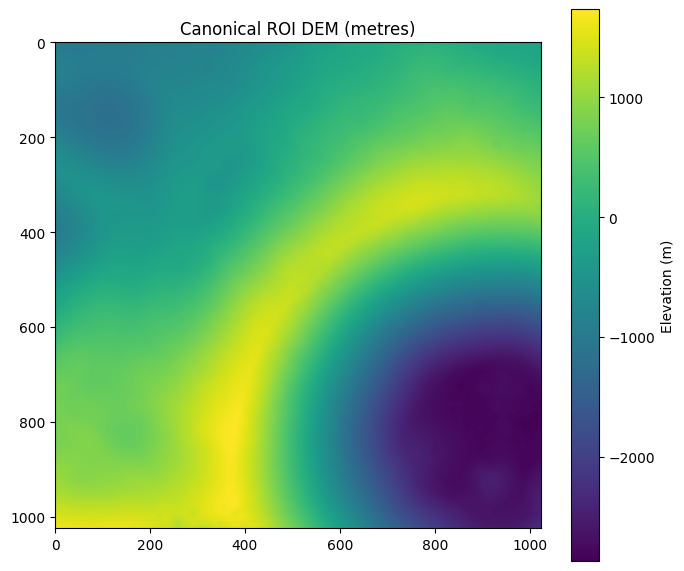

In [4]:
# Visual 1: DEM
plt.figure(figsize=(7, 6))
plt.imshow(dem_m)
plt.title("Canonical ROI DEM (metres)")
plt.colorbar(label="Elevation (m)")
plt.tight_layout()
plt.show()

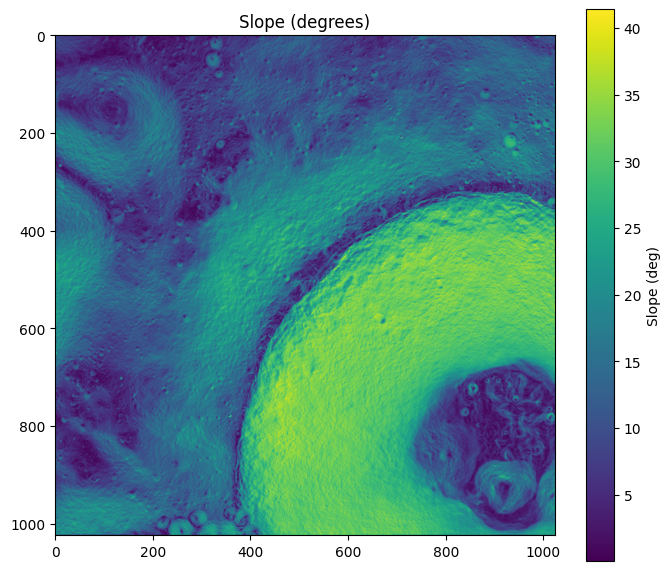

In [5]:
# Visual 2: Slope
plt.figure(figsize=(7, 6))
plt.imshow(slope_deg)
plt.title("Slope (degrees)")
plt.colorbar(label="Slope (deg)")
plt.tight_layout()
plt.show()

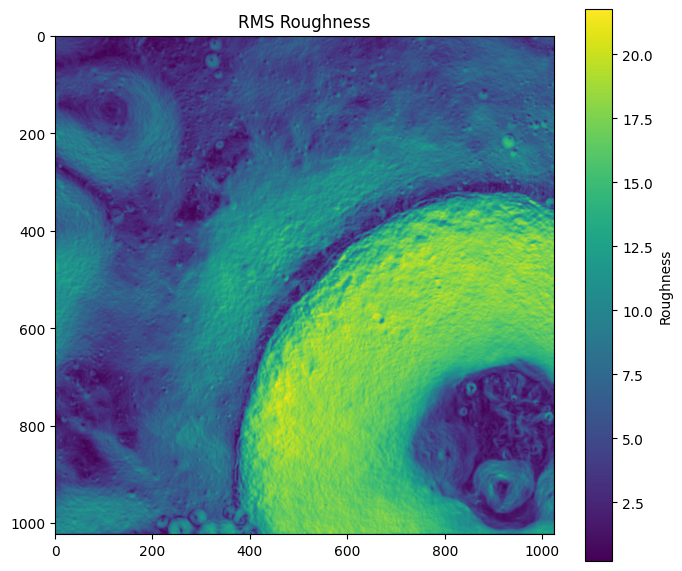

In [6]:
# Visual 3: Roughness
plt.figure(figsize=(7, 6))
plt.imshow(roughness_rms)
plt.title("RMS Roughness")
plt.colorbar(label="Roughness")
plt.tight_layout()
plt.show()

### Load and Visualise Navigation Rrun

In [ ]:
# - This cell loads one completed navigation run from the saved artefact contract:
#     hazard.npy, cost.npy, path_rc.npy, nav_meta.json, metrics.json
# - We also extract start/goal so the route plot is easier to read in the viva.

hazard = np.load(RUN_DIR / "hazard.npy")
cost = np.load(RUN_DIR / "cost.npy")
path_rc = np.load(RUN_DIR / "path_rc.npy")

with open(RUN_DIR / "nav_meta.json", "r", encoding="utf-8") as f:
    nav_meta = json.load(f)

nav = nav_meta.get("nav_meta", nav_meta)
start_rc = tuple(nav["start_rc"])
goal_rc = tuple(nav["goal_rc"])

metrics_path = RUN_DIR / "metrics.json"
metrics = None
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

print("Hazard shape:", hazard.shape)
print("Cost shape:", cost.shape)
print("Path nodes:", len(path_rc))
print("Start:", start_rc)
print("Goal :", goal_rc)
print("Success:", nav.get("result", {}).get("success", None))

Hazard shape: (1024, 1024)
Cost shape: (1024, 1024)
Path nodes: 155
Success: None


Plot Path Overlay 

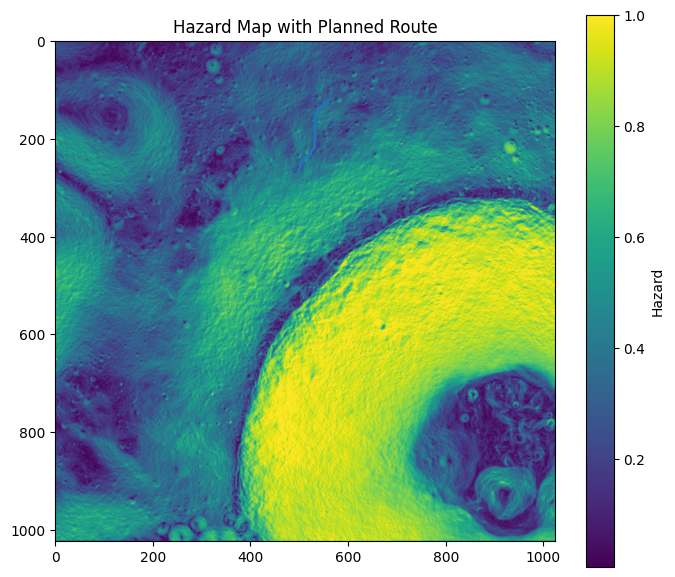

In [ ]:
# - This plot is intentionally presentation-focused.
# - The route is made thicker and the start/goal are marked clearly so the output is readable
#   during the FVD and the viva.

plt.figure(figsize=(8, 7))
plt.imshow(hazard)
plt.title("Hazard Map with Planned Route")
plt.colorbar(label="Hazard")

# Path
if len(path_rc) > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], linewidth=3, label="Route")

# Start and goal
plt.scatter(start_rc[1], start_rc[0], s=180, marker="*", label="Start")
plt.scatter(goal_rc[1], goal_rc[0], s=160, marker="X", label="Goal")

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Show Compact Metrics Summary 

In [ ]:
# Compact summary of one run

if metrics is not None:
    status = metrics.get("status", {})
    geometry = metrics.get("geometry", {})
    safety = metrics.get("safety", {})
    efficiency = metrics.get("efficiency", {})

    print("=== Run Summary ===")
    print("Success:", status.get("success"))
    print("Failure reason:", status.get("failure_reason"))
    print("Path length (m):", geometry.get("path_length_m"))
    print("Mean path hazard:", safety.get("path_hazard_mean"))
    print("Max path hazard:", safety.get("path_hazard_max"))
    print("Cost per metre:", efficiency.get("cost_per_m"))
    print("Expansions:", efficiency.get("expansions"))
else:
    print("metrics.json not found in RUN_DIR.")

### Simple Live Navigation Demo

This section launches one fresh route using the official CLI runner, then reloads the latest saved run so it can be inspected in the same notebook.

In [ ]:
# References / notes:
# - This cell runs one fresh route using the official Endymion CLI runner.
# - Use a known good ROI-local start/goal pair for a stable viva demo.
# - We keep the live run simple and controlled, rather than choosing random coordinates.

demo_start = (269, 499)
demo_goal = (122, 558)
live_prefix = "viva_live_demo"

cmd = [
    "python",
    "-m",
    "src.run_endymion",
    "--persistent-dir", str(PERSISTENT_DIR),
    "--runtime-dir", str(RUNTIME_DIR),
    "--tif-path", r"C:\Endymion\persistent\LDEM_80S_20MPP_ADJ.TIF",
    "--run-name", live_prefix,
    "--start", str(demo_start[0]), str(demo_start[1]),
    "--goal", str(demo_goal[0]), str(demo_goal[1]),
]

print("Running command:")
print(" ".join(cmd))
print("-" * 80)

result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)

if result.stderr:
    print("-" * 80)
    print("STDERR:")
    print(result.stderr)

print("Return code:", result.returncode)

In [ ]:
# References / notes:
# - This cell runs one fresh route using the official Endymion CLI runner.
# - Use a known good ROI-local start/goal pair for a stable viva demo.
# - We keep the live run simple and controlled, rather than choosing random coordinates.

demo_start = (269, 499)
demo_goal = (122, 558)
live_prefix = "viva_live_demo"

cmd = [
    "python",
    "-m",
    "src.run_endymion",
    "--persistent-dir", str(PERSISTENT_DIR),
    "--runtime-dir", str(RUNTIME_DIR),
    "--tif-path", r"C:\Endymion\persistent\LDEM_80S_20MPP_ADJ.TIF",
    "--run-name", live_prefix,
    "--start", str(demo_start[0]), str(demo_start[1]),
    "--goal", str(demo_goal[0]), str(demo_goal[1]),
]

print("Running command:")
print(" ".join(cmd))
print("-" * 80)

result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)

if result.stderr:
    print("-" * 80)
    print("STDERR:")
    print(result.stderr)

print("Return code:", result.returncode)

In [ ]:
# - This plot is intentionally presentation-focused.
# - The route is made thicker and the start/goal are marked clearly so the output is readable
#   during the FVD and the viva.

plt.figure(figsize=(8, 7))
plt.imshow(hazard)
plt.title("Hazard Map with Planned Route")
plt.colorbar(label="Hazard")

# Path
if len(path_rc) > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], linewidth=3, label="Route")

# Start and goal
plt.scatter(start_rc[1], start_rc[0], s=180, marker="*", label="Start")
plt.scatter(goal_rc[1], goal_rc[0], s=160, marker="X", label="Goal")

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Benchmark Summary Section

In [ ]:
# Load benchmark summary

benchmark_csv = BENCHMARK_DIR / "summary.csv"

if benchmark_csv.exists():
    bench_df = pd.read_csv(benchmark_csv)
    print("Loaded:", benchmark_csv)
    display(bench_df.head())
else:
    print("Benchmark summary.csv not found at:", benchmark_csv)

Benchmark summary.csv not found.


In [12]:
# Show only the most relevant benchmark columns
important_cols = [
    "hazard_model_id",
    "success_rate",
    "mean_path_hazard_mean",
    "mean_cost_per_m",
    "mean_expansions"
]

existing_cols = [c for c in important_cols if c in bench_df.columns]
bench_df[existing_cols]

NameError: name 'bench_df' is not defined

### ML bridge Section 

In [ ]:
# Load ML crater-probability output
ml_proba_path = ROI_DIR / "crater_proba_ml_v1.npy"

if ml_proba_path.exists():
    crater_proba = np.load(ml_proba_path)
    print("Crater probability shape:", crater_proba.shape, crater_proba.dtype)
else:
    crater_proba = None
    print("crater_proba_ml_v1.npy not found.")

In [ ]:
# Visual: ML crater probability raster

if crater_proba is not None:
    plt.figure(figsize=(7, 6))
    plt.imshow(crater_proba)
    plt.title("ML Crater Probability Output")
    plt.colorbar(label="Probability")
    plt.tight_layout()
    plt.show()

present summary metrics

In [ ]:
# Load ML summary JSON
if ML_SUMMARY_PATH.exists():
    with open(ML_SUMMARY_PATH, "r", encoding="utf-8") as f:
        ml_summary = json.load(f)

    print("=== ML Summary ===")
    print("Accuracy :", ml_summary.get("metrics", {}).get("accuracy"))
    print("Precision:", ml_summary.get("metrics", {}).get("precision"))
    print("Recall   :", ml_summary.get("metrics", {}).get("recall"))
    print("F1-score :", ml_summary.get("metrics", {}).get("f1"))
else:
    print("ML summary JSON not found.")

## Final takeaway

This notebook demonstrates that Endymion is not just a collection of experiments, but a reproducible hazard-navigation framework.

It shows:
- terrain-derived products loaded from a stable canonical ROI,
- hazard-aware route generation from saved pipeline artefacts,
- benchmark comparison under fixed planning conditions,
- and a machine-learning bridge that produces an ROI-aligned crater-probability raster.

In the final project, the terrain-only baseline remained the strongest overall in robustness and search effort, while crater-aware and ML-assisted variants demonstrated that richer hazard signals could be integrated and compared under the same controlled benchmark contract.

## Main CLI commands used in Endymion

Official pipeline runner:
`python -m src.run_endymion`

Benchmark runner:
`python benchmark\run_benchmark.py`

ML bridge:
`python -m src.run_crater_ml`

Author : Yair Cortes Torres - w20475998